In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import loadmat
from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter1d
from scipy import stats

sns.set_context("notebook")

%matplotlib widget

Loaded tracking data with 308232 timestamps and position shape (308232,) for x and (308232,) for y.


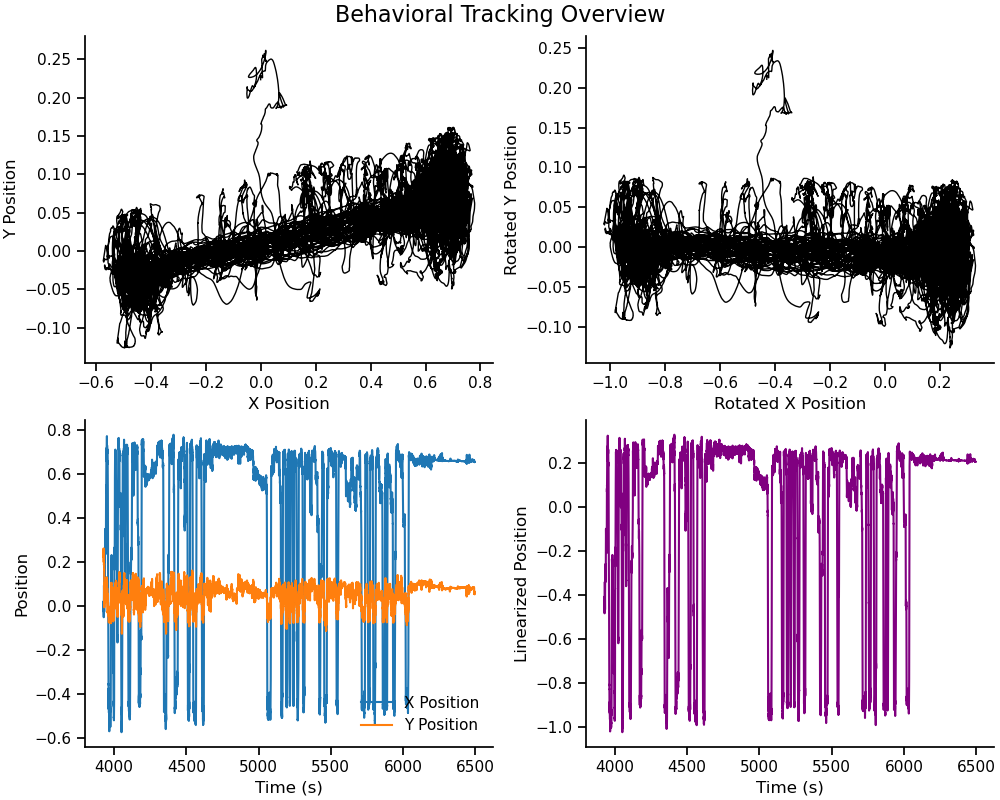

In [2]:
# Loading the position tracking data
tracking_file = '/mnt/home/srafilson/ceph/Bilat_R02_20251106/Bilat_R02_20251106_imec0.tracking.behavior.mat'
tracking = loadmat(tracking_file, squeeze_me=True)['tracking']

tracking_timestamps = tracking['timestamps'].item() # these are timestamps in seconds which are aligned to the raw spike times
position = tracking['position'].item()
x, y = np.array(position['x'].item()), np.array(position['y'].item())
print(f'Loaded tracking data with {len(tracking_timestamps)} timestamps and position shape {x.shape} for x and {y.shape} for y.')

# do PCA to linearize the position
positions = np.vstack((x, y)).T
positions_fit_pca = positions[500:-500]

pca = PCA(n_components=1)

# fit PCA only on trimmed data
pca.fit(positions_fit_pca)

# project ALL positions onto the learned axis
linearized_position = pca.transform(positions).flatten()

start_behavior_time = tracking_timestamps[0]
end_behavior_time = tracking_timestamps[-1]



fig, axs = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

# --- Top: XY trajectory ---
axs[0,0].plot(x, y, color="black", linewidth=1)
axs[0,0].set_xlabel("X Position")
axs[0,0].set_ylabel("Y Position")



# --- Bottom: Position over time ---
axs[1,0].plot(tracking_timestamps, x, label="X Position", linewidth=1.5)
axs[1,0].plot(tracking_timestamps, y, label="Y Position", linewidth=1.5)
axs[1,0].set_xlabel("Time (s)")
axs[1,0].set_ylabel("Position")
axs[1,0].legend(frameon=False)

# --- Optional: linearized position over time
axs[1,1].plot(tracking_timestamps, linearized_position, color="purple", linewidth=1.5)
axs[1,1].set_xlabel("Time (s)")
axs[1,1].set_ylabel("Linearized Position")


# rotate the XY trajectory by the angle of the first principal component for better visualization
angle = np.arctan2(pca.components_[0, 1], pca.components_[0, 0])

rotation_matrix = np.array([
    [np.cos(-angle), -np.sin(-angle)],
    [np.sin(-angle),  np.cos(-angle)]
])

rotated_positions = (positions - positions.mean(axis=0)) @ rotation_matrix.T
axs[0,1].plot(rotated_positions[:,0], rotated_positions[:,1], color="black", linewidth=1)
axs[0,1].set_xlabel("Rotated X Position")
axs[0,1].set_ylabel("Rotated Y Position")



sns.despine()
fig.suptitle("Behavioral Tracking Overview", fontsize=16)
plt.show()



Observations shape: (130600, 307)
Resampled linearized position to match observations: (130600,) vs 130600 time bins.
Plotting data from 5160 to 5430 seconds, corresponding to indices 63600 to 77100 in the time_bins array.


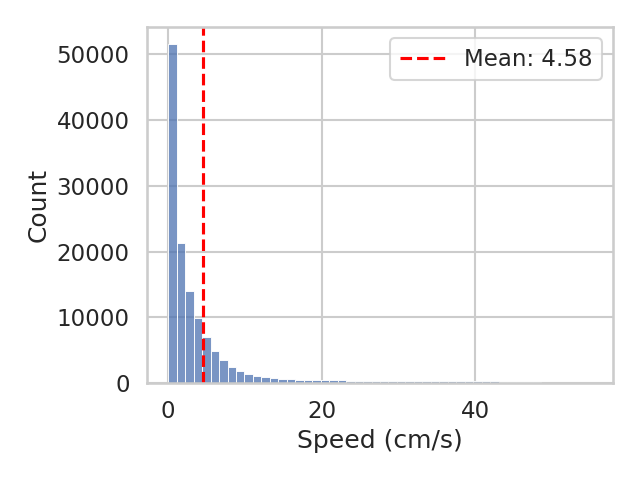

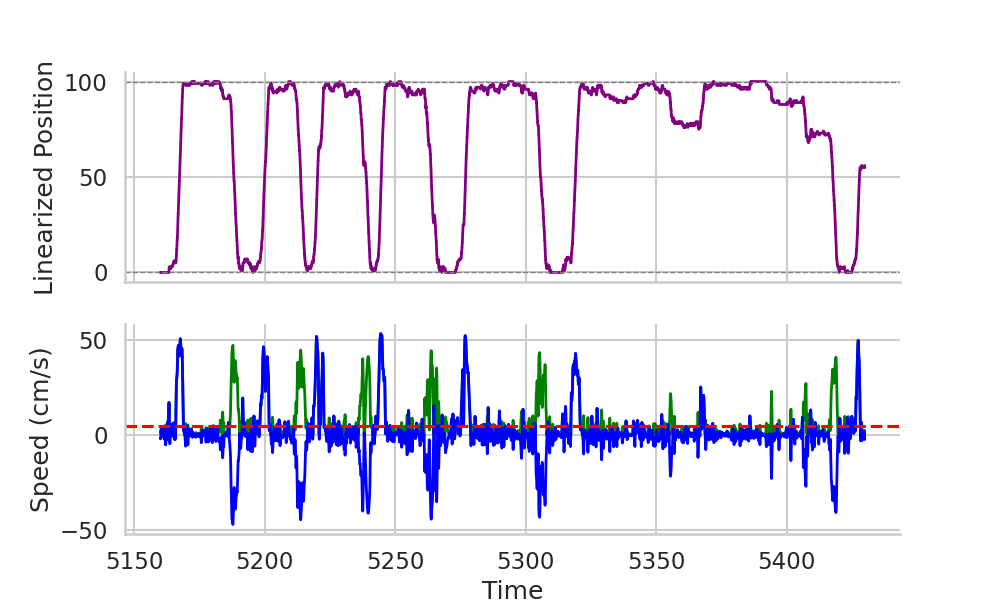

In [91]:
# Load the spike count data
data_path = '/mnt/home/srafilson/code/sequences/data/maze_clipped_spike_counts_Bilat_R02_20251106.npz'
data = np.load(data_path, allow_pickle=True)


# set the number of position bins
n_bins = 100


# get the observations and true states from the data
observations = data["observations"]
print(f"Observations shape: {observations.shape}")
if "states" in data:
    true_states = data["states"]
else:
    true_states = None

if "time_bins" in data:
    time_bins = data["time_bins"]
else:
    time_bins = None


# resample the linearized position so that each position corresponds to a time bin in the observations
if time_bins is not None:
    # get the start and end time of the observations
    start_time = time_bins[0]
    end_time = time_bins[-1]

    # resample the linearized position to match the number of time bins in the observations
    linearized_position_resampled = np.interp(time_bins, tracking_timestamps, linearized_position)

    print(f"Resampled linearized position to match observations: {linearized_position_resampled.shape} vs {observations.shape[0]} time bins.")

    # bin the linearized position into discrete states (e.g., 10 bins)
    linearized_position_binned = np.digitize(linearized_position_resampled, bins=np.linspace(np.percentile(linearized_position_resampled, 5), np.percentile(linearized_position_resampled, 85), n_bins))
else:
    linearized_position_resampled = None
    linearized_position_binned = None
    print("No time_bins found in the data. Skipping resampling of linearized position.")


# plot the linearized position and the speed 
start_sec = 5160
stop_sec = 5430

start = np.searchsorted(time_bins, start_sec)
stop = np.searchsorted(time_bins, stop_sec)
print(f"Plotting data from {start_sec} to {stop_sec} seconds, corresponding to indices {start} to {stop} in the time_bins array.")


velocity = gaussian_filter1d(np.gradient(linearized_position_resampled, time_bins), sigma=5) * 100

speed = np.abs(velocity)




mean_speed = np.mean(speed)

plt.figure()
sns.histplot(speed, bins=50)
plt.axvline(mean_speed, color='red', linestyle='--', label=f"Mean: {mean_speed:.2f}")
plt.legend()
plt.xlabel("Speed (cm/s)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(time_bins[start:stop], linearized_position_binned[start:stop], color='purple', linewidth=2)

# grey lines at top and bottom of the linearized position plot
ax[0].axhline(y=0, color='gray', linestyle='--', linewidth=1)
ax[0].axhline(y=n_bins, color='gray', linestyle='--', linewidth=1)

ax[0].set_ylabel("Linearized Position")
ax[1].plot(time_bins[start:stop-1], speed[start:stop-1], color='green', linewidth=2)
ax[1].plot(time_bins[start:stop-1], velocity[start:stop-1], color='blue', linewidth=2)
ax[1].axhline(mean_speed, color='red', linestyle='--', label=f"Mean: {mean_speed:.2f}")
ax[1].set_ylabel("Speed (cm/s)")
ax[1].set_xlabel("Time")
sns.despine()
plt.show()

## For single direction place fields use this cell:

Masked linearized position shape: (128465,)
Masked observations shape: (128465, 307)
Computed place fields shape: (307, 100)


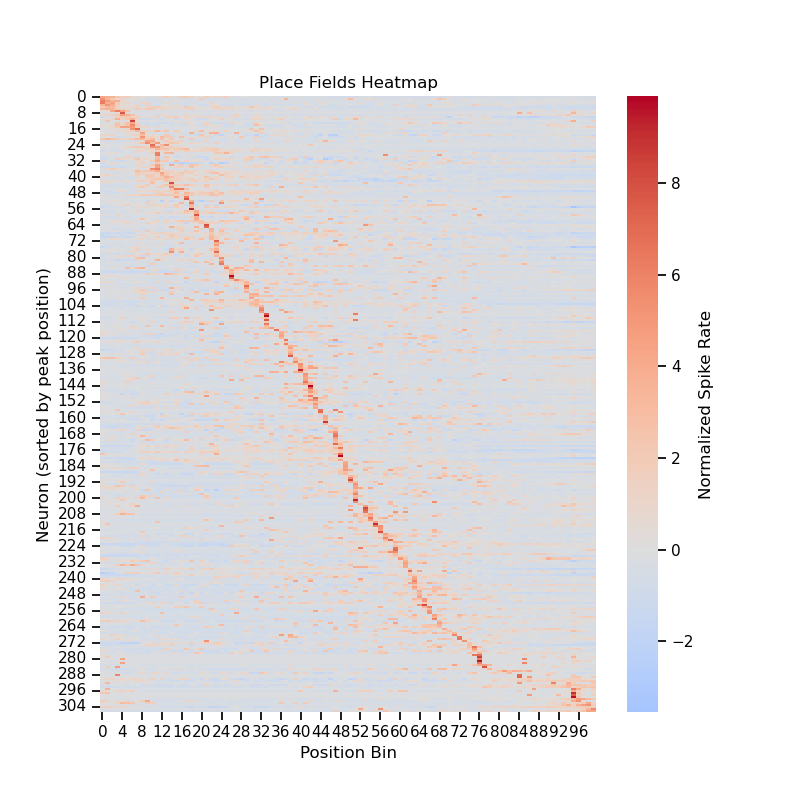

Expected rates shape: (307, 130600)
Observed counts shape: (307, 130600)
Log likelihood: (307,)


In [5]:
# for each neuron compute the place field (mean spike rate in each position bin) and use a max which is only when the speed is above threshold
speed_threshold = 0.
field_sigma = 0.4

speed_mask = speed > speed_threshold
linearized_position_masked = linearized_position_binned[speed_mask]
observations_masked = observations[speed_mask]
print(f"Masked linearized position shape: {linearized_position_masked.shape}")
print(f"Masked observations shape: {observations_masked.shape}")
# compute the place field for each neuron
n_neurons = observations_masked.shape[1]
place_fields = np.zeros((n_neurons, n_bins))
for neuron in range(n_neurons):
    for bin_idx in range(1, n_bins+1):
        mask = linearized_position_masked == bin_idx
        if np.any(mask):
            place_fields[neuron, bin_idx-1] = np.nanmean(observations_masked[mask, neuron])
        else:
            place_fields[neuron, bin_idx-1] = np.nan
print(f"Computed place fields shape: {place_fields.shape}")

# smooth the place fields along the position bins using a Gaussian filter
place_fields = gaussian_filter1d(place_fields, sigma=field_sigma, axis=1)




# plot a heatmap of the place fields sorted by the position of the peak
peak_positions = np.nanargmax(place_fields, axis=1)
sorted_indices = np.argsort(peak_positions)
plt.figure(figsize=(8, 8)) 
sns.heatmap(stats.zscore(place_fields[sorted_indices, :], axis=1), cmap='coolwarm', cbar_kws={'label': 'Normalized Spike Rate'}, center=0)
plt.xlabel("Position Bin")
plt.ylabel("Neuron (sorted by peak position)")
plt.title("Place Fields Heatmap")
plt.show()


# now compute the log likelihood of the data given a model with poisson spike counts

# for each time bin, get the expected rate from the place field corresponding to the linearized position
expected_rates = place_fields[:, linearized_position_binned - 1]  # shape (n_neurons, n_time_bins)
observed_counts = observations.T  # shape (n_neurons, n_time_bins)

# set any zero expected rates to a small value to avoid log(0)
expected_rates[expected_rates == 0] = 1e-10

# check shapes
print(f"Expected rates shape: {expected_rates.shape}")
print(f"Observed counts shape: {observed_counts.shape}")

# compute the log likelihood assuming Poisson statistics
log_likelihood = np.sum(stats.poisson.logpmf(observed_counts, expected_rates), axis = 1) # shape (n_neurons,)
print(f"Log likelihood: {log_likelihood.shape}")






## For directional place fields use this cell:

In [4]:
directions = [-1, 0, 1]  # possible movement directions

# for each neuron compute the place field (mean spike rate in each position bin) and use a max which is only when the speed is above threshold
speed_threshold = 0.043
field_sigma = 0.13

movement_direction = np.sign(velocity)
movement_direction[speed <= speed_threshold] = 0

all_place_fields = []

for direction in directions:
    print(f"Processing direction: {direction}")

    mask = (movement_direction == direction)
    linearized_position_masked = linearized_position_binned[mask]
    observations_masked = observations[mask]
    print(f"Masked linearized position shape: {linearized_position_masked.shape}")
    print(f"Masked observations shape: {observations_masked.shape}")

    # compute the place field for each neuron
    n_neurons = observations_masked.shape[1]
    place_fields = np.zeros((n_neurons, n_bins))
    for neuron in range(n_neurons):
        for bin_idx in range(1, n_bins+1):
            mask = linearized_position_masked == bin_idx
            if np.any(mask):
                place_fields[neuron, bin_idx-1] = np.nanmean(observations_masked[mask, neuron])
            else:
                place_fields[neuron, bin_idx-1] = 0
    print(f"Computed place fields shape: {place_fields.shape}")

    # smooth the place fields along the position bins using a Gaussian filter
    place_fields = gaussian_filter1d(place_fields, sigma=field_sigma, axis=1)

    # plot a heatmap of the place fields sorted by the position of the peak
    peak_positions = np.nanargmax(place_fields, axis=1)
    sorted_indices = np.argsort(peak_positions)
  
    all_place_fields.append(place_fields)



Processing direction: -1
Masked linearized position shape: (17719,)
Masked observations shape: (17719, 307)
Computed place fields shape: (307, 100)
Processing direction: 0
Masked linearized position shape: (95917,)
Masked observations shape: (95917, 307)
Computed place fields shape: (307, 100)
Processing direction: 1
Masked linearized position shape: (16964,)
Masked observations shape: (16964, 307)
Computed place fields shape: (307, 100)


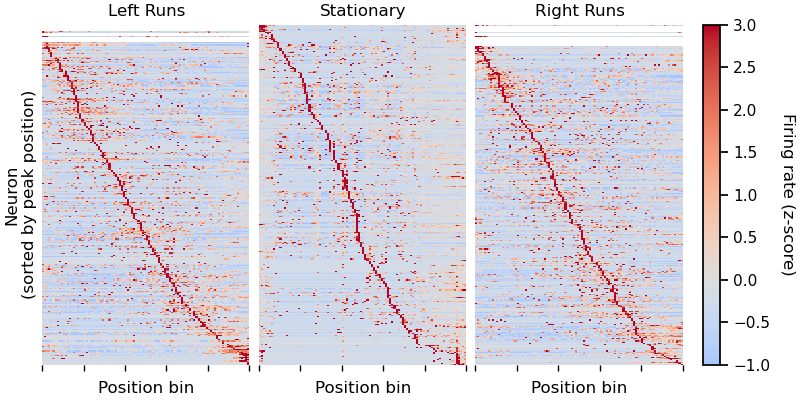

In [5]:
import matplotlib.ticker as ticker


# Plot the place fields
fig, axs = plt.subplots(
    1,
    len(directions),
    figsize=(8, 4),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

# Ensure axs is iterable when there is only one direction
axs = np.atleast_1d(axs)

heatmap = None

for ax, place_fields, direction in zip(
    axs, all_place_fields, directions
):
    peak_positions = np.nanargmax(place_fields, axis=1)
    sorted_indices = np.argsort(peak_positions)

    zscored_place_fields = stats.zscore(
        place_fields[sorted_indices, :],
        axis=1,
        nan_policy="omit"
    )

    heatmap = sns.heatmap(
        zscored_place_fields,
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=3,
        cbar=False,              
        ax=ax
    )


    # Labels you want displayed
    x_labels = np.array([0, 20, 40, 60, 80, 100])

    # Heatmap cells are centered at 0.5, 1.5, 2.5, ...
    x_positions = x_labels + 0.5

    ax.set_xticks(x_positions)
    ax.set_xticklabels(
        x_labels,
        rotation=45,
        ha="right"
    )

    ax.set_yticks([])
    # add the x ticks
    ax.set_xticks([0, 20, 40, 60, 80, 100])


    ax.tick_params(
        axis='both',
        which='major',
        direction='out',
        length=4,
        width=1,
        bottom=True,
        left=True
    )


    ax.set_xlabel("Position bin")
    if direction == -1:
        title = 'Left Runs'
    elif direction == 1:
        title = 'Right Runs'
    else:
        title = 'Stationary'
    ax.set_title(title)






axs[0].set_ylabel("Neuron\n(sorted by peak position)")

# Add one shared colorbar for all panels
colorbar = fig.colorbar(
    heatmap.collections[0],
    ax=axs,
    orientation="vertical",
    fraction=0.035,
    pad=0.03
)

colorbar.set_label(
    "Firing rate (z-score)",
    rotation=270,
    labelpad=18
)


plt.show()




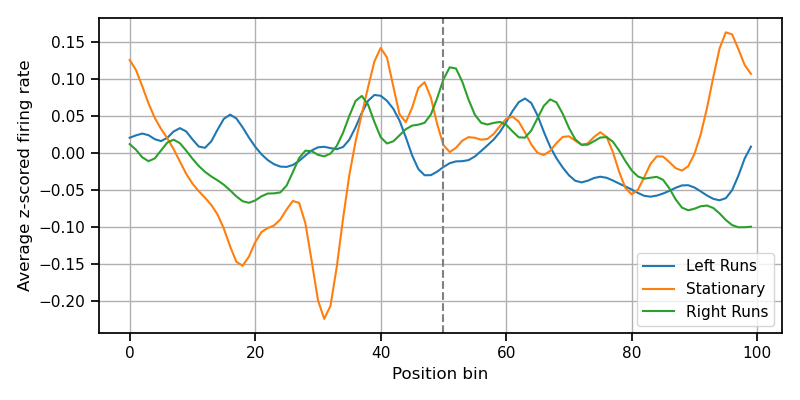

In [6]:
# plot the average zscored firing rate across all neurons for all 3 running directions
average_zscored_firing_rates = [np.nanmean(stats.zscore(place_fields, axis=1, nan_policy="omit"), axis=0) for place_fields in all_place_fields]

plt.figure(figsize=(8, 4))
for avg_firing_rate, direction in zip(average_zscored_firing_rates, directions):
    if direction == -1:
        label = 'Left Runs'
    elif direction == 1:
        label = 'Right Runs'
    else:
        label = 'Stationary'
    plt.plot(gaussian_filter1d(avg_firing_rate, sigma=2), label=label)

plt.axvline(x=50, color='gray', linestyle='--')


# grid
plt.grid(True)
plt.xlabel("Position bin")
plt.ylabel("Average z-scored firing rate")
plt.legend()
plt.tight_layout()
plt.show()


In [6]:




# for each time bin, get the expected rate from the place field corresponding to the linearized position
expected_rates = np.zeros((observations.shape[1], observations.shape[0]))  # shape (n_neurons, n_time_bins)
for direction, place_fields in zip(directions, all_place_fields):
    mask = movement_direction == direction
    expected_rates[:, mask] = place_fields[:, linearized_position_binned[mask] - 1]
observed_counts = observations.T  # shape (n_neurons, n_time_bins)

# set any zero expected rates to a small value to avoid log(0)
expected_rates[expected_rates == 0] = 1e-10

# check shapes
print(f"Expected rates shape: {expected_rates.shape}")
print(f"Observed counts shape: {observed_counts.shape}")

# compute the log likelihood assuming Poisson statistics
log_likelihood = stats.poisson.logpmf(observed_counts, expected_rates) # shape (Neurons x Time)
print(f"Log likelihood: {log_likelihood.shape}")



Expected rates shape: (307, 130600)
Observed counts shape: (307, 130600)
Log likelihood: (307, 130600)


In [7]:
# read in the model likelihoods
model_llhs = np.load('model_likelihoods_all_times.npy')
print(model_llhs.shape)




(307, 130600)


/tmp/ipykernel_3382157/1009404141.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


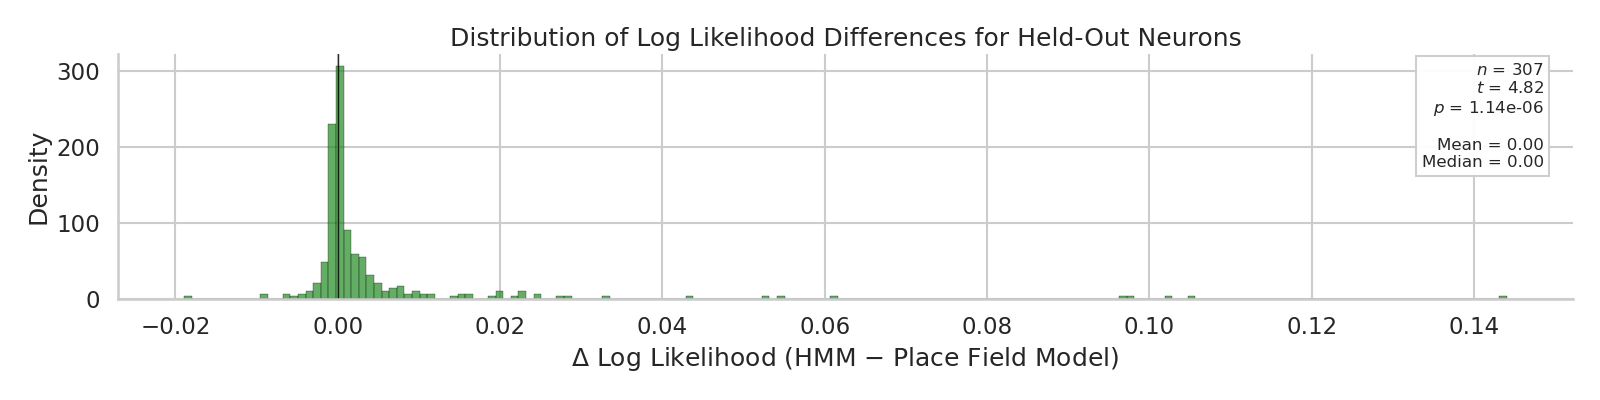

In [8]:

# Statistical comparison
diffs = np.mean(model_llhs, axis = 1) - np.mean(log_likelihood, axis = 1)[:len(model_llhs)]


t_stat, p_value = stats.ttest_1samp(diffs, 0, alternative='greater')

# -------------------------------------------------------------------------
sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(16, 4))

# Histogram
sns.histplot(
    diffs,
    #bins = 140,
    # bins="fd",
    stat="density",
    color="forestgreen",
    edgecolor="black",
    alpha=0.7,
    linewidth=.2,
    ax=ax,
)

# Zero reference
ax.axvline(
    0,
    color="black",
    linewidth=1,
    linestyle="-",
    alpha=0.8,
)

if False:

    # Mean
    ax.axvline(
        np.mean(diffs),
        color="crimson",
        linewidth=2,
        linestyle="--",
        label=f"Mean = {np.mean(diffs):.2f}",
    )

    # Median
    ax.axvline(
        np.median(diffs),
        color="royalblue",
        linewidth=2,
        linestyle="--",
        label=f"Median = {np.median(diffs):.2f}",
    )


# Annotation
ax.text(
    0.98,
    0.97,
    f"$n$ = {len(diffs)}\n"
    f"$t$ = {t_stat:.2f}\n"
    f"$p$ = {p_value:.2e}\n\n"
    f"Mean = {np.mean(diffs):.2f}\n"
    f"Median = {np.median(diffs):.2f}",

    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=12,
    bbox=dict(facecolor="white", edgecolor="0.8", alpha=0.95),
)

ax.set(
    xlabel=r"$\Delta$ Log Likelihood (HMM $-$ Place Field Model)",
    ylabel="Density",
)

# title
ax.set_title("Distribution of Log Likelihood Differences for Held-Out Neurons")

ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

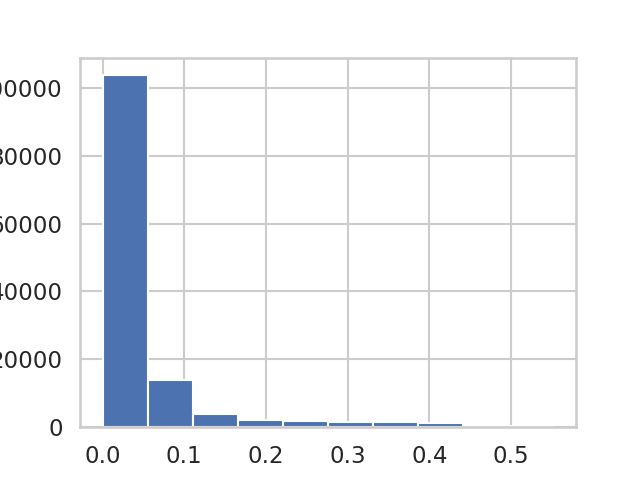

In [20]:
plt.figure()
plt.hist(speed)
plt.show()

In [96]:
from tqdm.auto import tqdm
import numpy as np

n_iters = 1000

max_speed = 30

step = 1
n_units = model_llhs.shape[0]

assert model_llhs.shape[1] == len(speed)
assert log_likelihood.shape[1] == len(speed)
assert log_likelihood.shape[0] >= n_units

rng = np.random.default_rng(42)

# Population-average LLH difference at each time point
timepoint_diffs = np.mean(
    model_llhs - log_likelihood[:n_units],
    axis=0,
)

# Convert percentile edges into speed values
speed_edges = np.arange(0, max_speed + step, step)

n_bins = len(speed_edges) - 1

all_diffs = np.full(
    (n_bins, n_iters),
    np.nan,
    dtype=float,
)

n_samples = np.zeros(n_bins, dtype=int)

for bin_idx in tqdm(range(n_bins)):

    lower = speed_edges[bin_idx]
    upper = speed_edges[bin_idx + 1]

    # Include the upper edge only in the final bin
    if bin_idx == n_bins - 1:
        speed_mask = (speed >= lower) & (speed <= upper)
    else:
        speed_mask = (speed >= lower) & (speed < upper)

    valid_diffs = timepoint_diffs[speed_mask]
    n_valid = valid_diffs.size
    n_samples[bin_idx] = n_valid

    if n_valid == 0:
        continue

    bootstrap_idx = rng.integers(
        low=0,
        high=n_valid,
        size=(n_iters, n_valid),
    )

    all_diffs[bin_idx] = valid_diffs[bootstrap_idx].mean(axis=1)

  0%|          | 0/30 [00:00<?, ?it/s]

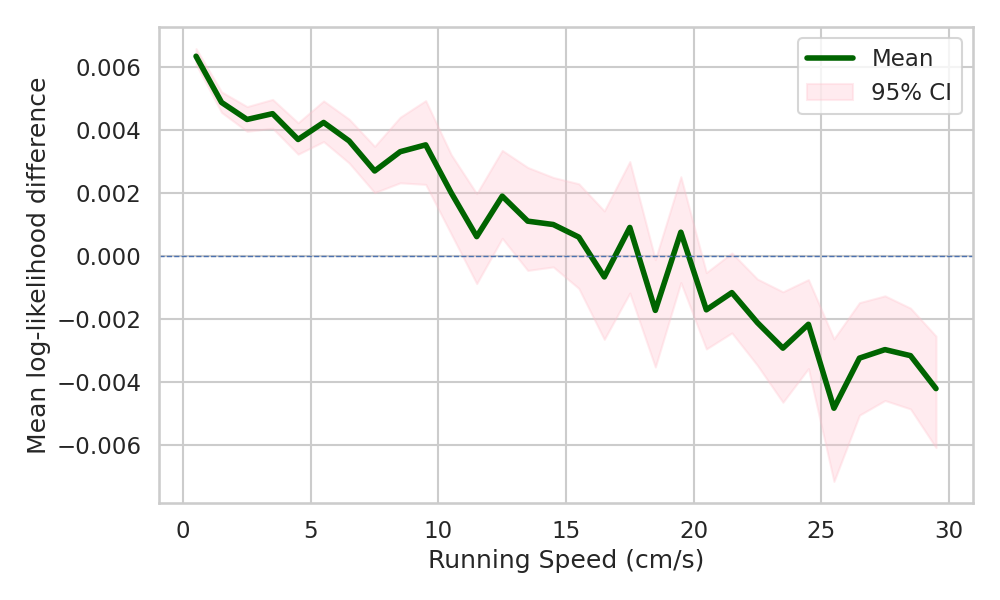

In [97]:
speed_centers = (
    speed_edges[:-1] + speed_edges[1:]
) / 2

mean_diffs = np.nanmean(all_diffs, axis=1)
lower_bound = np.nanpercentile(all_diffs, 2.5, axis=1)
upper_bound = np.nanpercentile(all_diffs, 97.5, axis=1)


plt.figure(figsize=(10, 6))

plt.plot(speed_centers, mean_diffs, label = 'Mean', color = 'darkgreen', linewidth = 4)
plt.fill_between(
    speed_centers,
    lower_bound,
    upper_bound,
    color = 'pink',
    alpha=0.3,
    label = '95% CI'
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.legend()
plt.xlabel("Running Speed (cm/s)")
plt.ylabel("Mean log-likelihood difference")
plt.tight_layout()
plt.show()

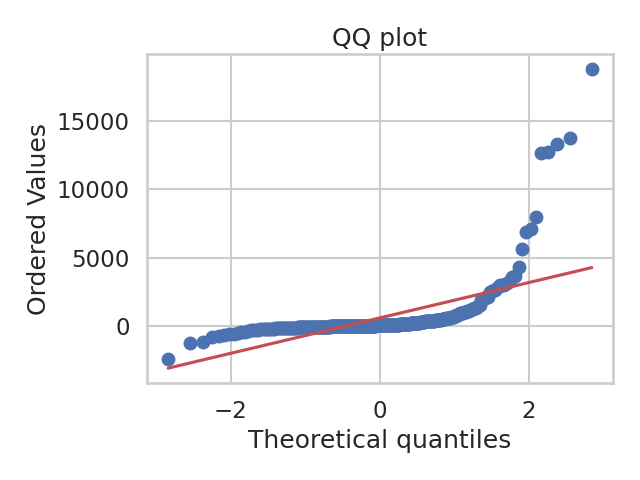

5.481947044677863
34.78671009481887
574.0002202164055
24.575412533273195
[ -841.11577646  -280.5787647    -60.79286897    24.57541253
   353.60513926  3005.52673266 12737.48521273]
[ 5.22622605e+02  4.68724832e+01  4.51485397e+02 -8.44982110e+02
  3.98174484e+02  2.45754125e+01  1.28043266e+02  2.17180550e+02
  1.22576649e+02  9.48810025e+00 -2.28531468e+01  9.70176203e+00
 -1.34510438e+02 -5.24718725e+01  5.35758686e+02 -2.58739382e+01
  1.47065982e+02  9.21976154e+00 -9.54591392e+01  3.78142068e+02
 -2.44590095e+02 -1.55116947e+01 -2.30854290e+01 -2.34339404e+01
 -1.83377204e+02 -1.87397017e+02  1.28818874e+01 -5.45612053e+01
  3.41376930e+02  5.47244902e+01 -2.24323824e+01 -3.24625405e+01
  4.73691370e+02  9.53891251e+02 -3.47265219e+01 -5.74161279e+00
 -9.36971270e+01  3.26110907e+02 -1.71774822e+02 -7.76028460e+01
  2.61876270e+02  6.48102638e+02 -1.39410531e+01 -1.68608306e+01
  2.14823427e+01  2.22036036e+02 -6.32480349e+01 -4.21218737e+01
 -1.20733574e+01  1.66860111e+02  2.255

In [ ]:


plt.figure()
stats.probplot(diffs, plot=plt)
plt.tight_layout()
plt.title("QQ plot")
plt.show()


from scipy.stats import skew, kurtosis

print(skew(diffs))
print(kurtosis(diffs, fisher=True))

print(np.mean(diffs))
print(np.median(diffs))

print(np.percentile(diffs,[1,5,25,50,75,95,99]))

In [ ]:
# grid search over smoothing and speed threshold to maximize likelihood
smoothing_sigmas = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]
speed_thresholds = [0.0, 0.01, 0.02, 0.03, 0.04,  0.05, 0.06]




all_log_likelihoods = []
for speed_threshold in speed_thresholds:

    speed_mask = speed > speed_threshold
    linearized_position_masked = linearized_position_binned[speed_mask]
    observations_masked = observations[speed_mask]
    print(f"Masked linearized position shape: {linearized_position_masked.shape}")
    print(f"Masked observations shape: {observations_masked.shape}")

    # compute the place field for each neuron
    n_neurons = observations_masked.shape[1]
    place_fields_grid = np.zeros((n_neurons, n_bins))
    for neuron in range(n_neurons):
        for bin_idx in range(1, n_bins+1):
            mask = linearized_position_masked == bin_idx
            if np.any(mask):
                place_fields_grid[neuron, bin_idx-1] = np.nanmean(observations_masked[mask, neuron])
            else:
                place_fields_grid[neuron, bin_idx-1] = np.nan
    
    for sigma in smoothing_sigmas:
        if sigma > 0:
            place_fields_smoothed = gaussian_filter1d(place_fields_grid, sigma=sigma, axis=1)
        else:
            # gaussian_filter1d divides by sigma**2 internally, so sigma=0 (no smoothing) must be handled separately
            place_fields_smoothed = place_fields_grid

        # for each time bin, get the expected rate from the place field corresponding to the linearized position
        expected_rates = place_fields_smoothed[:, linearized_position_binned - 1]  # shape (n_neurons, n_time_bins)
        observed_counts = observations.T  # shape (n_neurons, n_time_bins)

        # set any zero expected rates to a small value to avoid log(0)
        expected_rates[expected_rates == 0] = 1e-10

        # compute the log likelihood assuming Poisson statistics
        log_likelihood = np.sum(stats.poisson.logpmf(observed_counts, expected_rates))
        
        all_log_likelihoods.append((speed_threshold, sigma, log_likelihood))
        print(f"Appended log likelihood for speed_threshold={speed_threshold}, sigma={sigma}: {log_likelihood}")

In [ ]:
# plot the log likelihoods as a function of speed threshold and smoothing sigma (heatmap)
import matplotlib.pyplot as plt
# convert the list of log likelihoods to a 2D array for plotting
log_likelihoods_array = np.zeros((len(speed_thresholds), len(smoothing_sigmas)))
for speed_idx, speed_threshold in enumerate(speed_thresholds):
    for sigma_idx, sigma in enumerate(smoothing_sigmas):
        matching = [ll for st, s, ll in all_log_likelihoods if st == speed_threshold and s == sigma]
        if matching:
            log_likelihoods_array[speed_idx, sigma_idx] = matching[0]
        else:
            log_likelihoods_array[speed_idx, sigma_idx] = np.nan

plt.figure()
plt.imshow(log_likelihoods_array, aspect='auto', origin='lower')
plt.colorbar(label='Log Likelihood')
plt.xlabel('Place Field Smoothing Sigma')
plt.ylabel('Running Speed Threshold')
plt.title('Log Likelihood of Place Field Model')
# tick at each pixel index and label with the actual parameter value, so labels land
# on cell centers regardless of whether the sigma/threshold values are evenly spaced
plt.xticks(np.arange(len(smoothing_sigmas)), smoothing_sigmas, rotation=45)
plt.yticks(np.arange(len(speed_thresholds)), speed_thresholds)

plt.show()


In [ ]:
# do the grid search but with the directional place fields

# grid search over smoothing and speed threshold to maximize likelihood
smoothing_sigmas = [0., 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4, 0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5]
speed_thresholds = [0., 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.01, 0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018, 0.019, 0.02, 0.021, 0.022, 0.023, 0.024, 0.025, 0.026, 0.027, 0.028, 0.029, 0.03, 0.031, 0.032, 0.033, 0.034, 0.035, 0.036, 0.037, 0.038, 0.039, 0.04, 0.041, 0.042, 0.043, 0.044, 0.045, 0.046, 0.047, 0.048, 0.049, 0.05, 0.051, 0.052, 0.053, 0.054, 0.055, 0.056, 0.057, 0.058, 0.059, 0.06, 0.061, 0.062, 0.063, 0.064, 0.065, 0.066, 0.067, 0.068, 0.069, 0.07, ]


directions = [-1, 0, 1]  # possible movement directions

directional_log_likelihoods = []
for speed_threshold in speed_thresholds:

    movement_direction = np.sign(velocity)
    movement_direction[speed <= speed_threshold] = 0

    # compute the raw (unsmoothed) place field for each neuron, per direction, once per speed_threshold
    raw_place_fields_by_direction = {}
    for direction in directions:
        direction_mask = (movement_direction == direction)
        linearized_position_masked = linearized_position_binned[direction_mask]
        observations_masked = observations[direction_mask]
        print(f"speed_threshold={speed_threshold}, direction={direction}: masked position shape {linearized_position_masked.shape}, masked observations shape {observations_masked.shape}")

        n_neurons = observations_masked.shape[1]
        place_fields_grid = np.zeros((n_neurons, n_bins))
        for neuron in range(n_neurons):
            for bin_idx in range(1, n_bins+1):
                mask = linearized_position_masked == bin_idx
                if np.any(mask):
                    place_fields_grid[neuron, bin_idx-1] = np.nanmean(observations_masked[mask, neuron])
                else:
                    place_fields_grid[neuron, bin_idx-1] = 0

        raw_place_fields_by_direction[direction] = place_fields_grid

    for sigma in smoothing_sigmas:
        # for each time bin, get the expected rate from the place field for its direction, corresponding to the linearized position
        expected_rates = np.zeros((observations.shape[1], observations.shape[0]))  # shape (n_neurons, n_time_bins)
        for direction in directions:
            if sigma > 0:
                place_fields_smoothed = gaussian_filter1d(raw_place_fields_by_direction[direction], sigma=sigma, axis=1)
            else:
                # gaussian_filter1d divides by sigma**2 internally, so sigma=0 (no smoothing) must be handled separately
                place_fields_smoothed = raw_place_fields_by_direction[direction]
            direction_mask = (movement_direction == direction)
            expected_rates[:, direction_mask] = place_fields_smoothed[:, linearized_position_binned[direction_mask] - 1]

        observed_counts = observations.T  # shape (n_neurons, n_time_bins)

        # set any zero expected rates to a small value to avoid log(0)
        expected_rates[expected_rates == 0] = 1e-10

        # compute the log likelihood assuming Poisson statistics
        log_likelihood = np.sum(stats.poisson.logpmf(observed_counts, expected_rates))

        directional_log_likelihoods.append((speed_threshold, sigma, log_likelihood))
        print(f"Appended directional log likelihood for speed_threshold={speed_threshold}, sigma={sigma}: {log_likelihood}")

In [ ]:
sns.set_theme(style="white", context="talk")

# plot the directional log likelihoods as a function of speed threshold and smoothing sigma (heatmap)
directional_log_likelihoods_array = np.zeros((len(speed_thresholds), len(smoothing_sigmas)))
for speed_idx, speed_threshold in enumerate(speed_thresholds):
    for sigma_idx, sigma in enumerate(smoothing_sigmas):
        matching = [ll for st, s, ll in directional_log_likelihoods if st == speed_threshold and s == sigma]
        if matching:
            directional_log_likelihoods_array[speed_idx, sigma_idx] = matching[0]
        else:
            directional_log_likelihoods_array[speed_idx, sigma_idx] = np.nan

best_idx = np.nanargmax(directional_log_likelihoods_array)
best_speed_idx, best_sigma_idx = np.unravel_index(best_idx, directional_log_likelihoods_array.shape)

# save the directional log likelihoods to npy file
np.save("directional_log_likelihoods.npy", directional_log_likelihoods_array)



In [ ]:
from matplotlib import colormaps

# load the directional log likelihoods from the npy file
directional_log_likelihoods_array = np.load("directional_log_likelihoods.npy")

colormap = colormaps['nipy_spectral']
plt.figure(figsize=(8, 6))

plt.imshow(
    directional_log_likelihoods_array[:, :],
    aspect='auto', origin='lower', cmap = colormap,
    vmin = np.percentile(directional_log_likelihoods_array, 5),
    vmax = np.percentile(directional_log_likelihoods_array, 100),
    extent=[smoothing_sigmas[0], smoothing_sigmas[-1], speed_thresholds[0], speed_thresholds[-1]],
    interpolation='gaussian'
)

# put a start at the peak
plt.scatter(
    smoothing_sigmas[best_sigma_idx],
    speed_thresholds[best_speed_idx],
    color='teal',
    marker='*',
    s=200,
    edgecolor='black'
)



plt.colorbar(label='Log Likelihood')
plt.xlabel('Place Field Smoothing Sigma')
plt.ylabel('Running Speed Threshold')
#sns.despine(bottom=True, left=True) 

plt.tight_layout()
plt.show()


print(f"Best speed_threshold={speed_thresholds[best_speed_idx]}, sigma={smoothing_sigmas[best_sigma_idx]}, log_likelihood={directional_log_likelihoods_array[best_speed_idx, best_sigma_idx]}")
